In [118]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [119]:
# Load historical data using yfinance

ticker = "AAPL"
df = yf.download(ticker, start="2024-01-01", end="2026-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [120]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600
2024-01-05,179.152084,180.714402,178.153394,179.953031,62379700
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500


In [121]:
#Use features like Open, High, Low, and Volume to predict the next Close price.
df["Next_Close"] = df["Close"].shift(-1)
df = df.dropna()
df.head()



Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700,182.187744
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500,179.873932
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600,179.152084
2024-01-05,179.152084,180.714402,178.153394,179.953031,62379700,183.483063
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500,183.067810


In [122]:
# feature X
X = df[["Open", "High", "Low", "Volume"]]

# feature y
y = df['Next_Close']


In [124]:
X.head()

Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-02,185.055258,186.330827,181.831752,82488700
2024-01-03,182.158081,183.799505,181.376915,58414500
2024-01-04,180.111236,181.040717,178.855462,71983600
2024-01-05,179.953031,180.714402,178.153394,62379700
2024-01-08,180.051901,183.522623,179.468508,59144500


In [123]:
y.head()

,Next_Close
Date,
2024-01-02,182.187744
2024-01-03,179.873932
2024-01-04,179.152084
2024-01-05,183.483063
2024-01-08,183.067810


In [125]:
# train_text_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [127]:
# predict the model
y_pred = model.predict(X_test)

In [128]:
y_pred

array([197.73188057, 167.81696152, 211.26859831, 220.52651099,
       189.78644998, 207.98141643, 209.32352358, 214.72768643,
       166.37454896, 261.86948861, 181.13014231, 227.14444508,
       231.21152224, 170.53636484, 277.49397915, 239.45913532,
       270.94058269, 181.61221383, 187.38804413, 226.46989067,
       273.91278348, 272.84457433, 239.10536714, 204.44059572,
       165.05951365, 269.81347404, 273.89618218, 222.51830908,
       189.38206206, 202.67429825, 226.20704554, 198.47810511,
       255.95128546, 217.79946073, 180.19531623, 212.49534194,
       224.11526407, 176.06773131, 229.31920268, 168.8820077 ,
       254.65964883, 188.39101699, 278.4362087 , 225.34866001,
       179.40223218, 165.13936696, 183.65373517, 186.57278955,
       231.99067317, 183.45512253, 169.01632558, 226.38312781,
       225.69350864, 227.58006711, 223.48147783, 170.64256581,
       206.10120036, 188.37715648, 228.06611329, 167.21416192,
       271.51279798, 228.02598815, 194.32338903, 278.71

In [129]:
# simple plot
test_dates = df.index[-len(y_test) :]

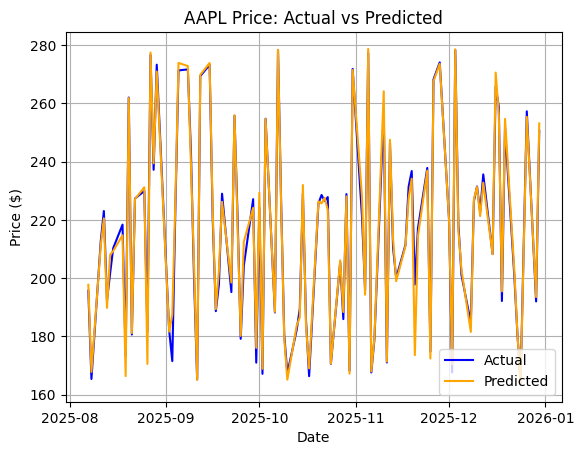

In [133]:
# Actual Price Line
plt.plot(test_dates, y_test, label="Actual", color="blue")

# Predicted Price Line
plt.plot(test_dates, y_pred, label="Predicted", color="orange")

# Labels
plt.title("AAPL Price: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()